In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

In [5]:
# Path to dataset
dataset_path = "PlantVillage"

# Check classes
classes = os.listdir(dataset_path)
print("Classes:", classes)


Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']


In [6]:
IMG_SIZE = 128
data = []
labels = []

for category in classes:
    path = os.path.join(dataset_path, category)
    for img in os.listdir(path):
        try:
            img_array = cv2.imread(os.path.join(path, img))
            resized = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
            data.append(resized)
            labels.append(category)
        except Exception as e:
            pass

data = np.array(data) / 255.0
labels = np.array(labels)


In [7]:
lb = LabelBinarizer()
labels = lb.fit_transform(labels)
print("Encoded Labels Shape:", labels.shape)


Encoded Labels Shape: (20638, 15)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)


In [19]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2, 
    horizontal_flip=True,
    fill_mode="nearest"
)
datagen.fit(X_train)


In [10]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


C:\Users\parth\OneDrive\Desktop\tensorflow\tfvenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 15)                  │           3,855 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,519,887 (24.87 MB)

 Trainable params: 6,519,887 (24.87 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",   # or sparse_categorical_crossentropy
    metrics=["accuracy"]
)


In [12]:
early_stop = EarlyStopping(monitor='val_loss', patience=5)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=25,
    callbacks=[early_stop]
)

C:\Users\parth\OneDrive\Desktop\tensorflow\tfvenv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 102s 193ms/step - accuracy: 0.4062 - loss: 1.8258 - val_accuracy: 0.6427 - val_loss: 1.0317
Epoch 2/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 96s 185ms/step - accuracy: 0.6254 - loss: 1.1306 - val_accuracy: 0.7631 - val_loss: 0.6840
Epoch 3/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 92s 178ms/step - accuracy: 0.7053 - loss: 0.8728 - val_accuracy: 0.7834 - val_loss: 0.6350
Epoch 4/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 86s 166ms/step - accuracy: 0.7448 - loss: 0.7631 - val_accuracy: 0.8081 - val_loss: 0.5618
Epoch 5/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 98s 190ms/step - accuracy: 0.7847 - loss: 0.6484 - val_accuracy: 0.8137 - val_loss: 0.5568
Epoch 6/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 86s 166ms/step - accuracy: 0.8020 - loss: 0.5884 - val_accuracy: 0.8944 - val_loss: 0.3127
Epoch 7/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 89s 172ms/step - accuracy: 0.8248 - loss: 0.5246 - val_accuracy: 0.9000 - val_loss: 0.3021
Epoch 8/25
516/516 ━━━━━━━━━━━━━━━━━━━━ 103s 200ms/step - accuracy: 0.8396 - loss:

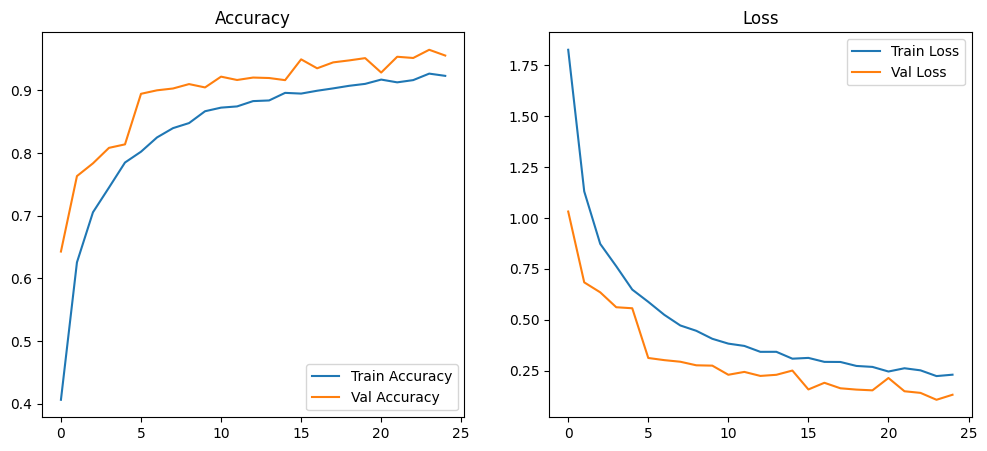

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()


In [14]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")


129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9554 - loss: 0.1322
Test Accuracy: 95.54%


In [15]:
model.save("crop_disease_model.h5")


In [16]:
def predict_image(img_path):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Image not found or cannot be opened: {img_path}")
    
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)
    class_idx = np.argmax(pred)
    print("Predicted Class:", lb.classes_[class_idx])


In [17]:
import os
print(os.path.abspath("PlantVillage/Tomato___Bacterial_spot/001.jpg"))


C:\Users\parth\OneDrive\Desktop\tensorflow\PlantVillage\Tomato___Bacterial_spot\001.jpg


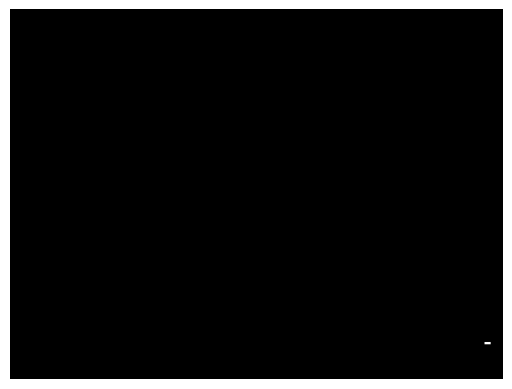

In [18]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(0)  # webcam

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Show with matplotlib
    plt.imshow(gray, cmap='gray')
    plt.axis("off")
    plt.show()

    break  # remove this to show continuously

cap.release()


In [21]:
# Save model
model.save("crop_disease_model.h5")

# Save class labels (replace lb.classes_ with your label encoder variable)
import numpy as np
np.save("classes.npy", lb.classes_)
